# Advanced Analytics for Mutual Fund Performance

## Objectives

This notebook performs advanced financial and investor analytics on the mutual fund dataset.

The analyses included are:

- Historical Value at Risk (VaR)
- Conditional Value at Risk (CVaR)
- Rolling 90-Day Sharpe Ratio
- Investor Cohort Analysis
- SIP Continuity Analysis
- Fund Recommendation System
- Sector Concentration Analysis (HHI)

These analyses help evaluate downside risk, investor behaviour, portfolio concentration, and fund recommendations based on risk profiles.

In [49]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

In [50]:
BASE_DIR = Path("..")

DATA_DIR = BASE_DIR / "data"

PROCESSED_DIR = DATA_DIR / "processed"
ANALYTICS_DIR = DATA_DIR / "analytics"

REPORT_DIR = BASE_DIR / "reports" / "charts"

REPORT_DIR.mkdir(parents=True, exist_ok=True)

In [51]:
daily_returns_df = pd.read_csv(
    ANALYTICS_DIR / "daily_returns.csv",
    parse_dates=["date"]
)

fund_scorecard_df = pd.read_csv(
    ANALYTICS_DIR / "fund_scorecard.csv"
)

investor_df = pd.read_csv(
    PROCESSED_DIR / "clean_investor_transactions.csv",
    parse_dates=["transaction_date"]
)

portfolio_df = pd.read_csv(
    PROCESSED_DIR / "clean_portfolio_holdings.csv"
)

scheme_df = pd.read_csv(
    PROCESSED_DIR / "clean_scheme_performance.csv"
)

In [52]:
print(daily_returns_df.shape)
print(fund_scorecard_df.shape)
print(investor_df.shape)
print(portfolio_df.shape)
print(scheme_df.shape)

(64320, 4)
(37, 10)
(32778, 13)
(322, 8)
(40, 21)


In [53]:
daily_returns_df.head()

,date,amfi_code,nav,daily_return
0,2022-01-03,100016,520.4608,NaN
1,2022-01-04,100016,515.0971,-0.010306
2,2022-01-05,100016,521.7239,0.012865
3,2022-01-06,100016,515.7880,-0.011377
4,2022-01-07,100016,515.1639,-0.001210


## Historical Value at Risk (VaR) and Conditional Value at Risk (CVaR)

Historical Value at Risk (VaR) estimates the maximum expected loss over a single trading day at a specified confidence level using historical returns.

For a 95% confidence level, VaR is calculated as the 5th percentile of the historical daily return distribution.

Conditional Value at Risk (CVaR), also known as Expected Shortfall, measures the average loss beyond the VaR threshold, providing additional insight into extreme downside risk.

In [54]:

returns_df = daily_returns_df.dropna(subset=["daily_return"]).copy()

risk_metrics = []

for amfi_code, group in returns_df.groupby("amfi_code"):

    returns = group["daily_return"]

    var_95 = np.percentile(returns, 5)

    cvar_95 = returns[returns <= var_95].mean()

    risk_metrics.append({
        "amfi_code": amfi_code,
        "VaR_95": var_95,
        "CVaR_95": cvar_95
    })

risk_df = pd.DataFrame(risk_metrics)

In [55]:
risk_df = risk_df.merge(
    fund_scorecard_df[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

risk_df = risk_df[
    [
        "amfi_code",
        "scheme_name",
        "VaR_95",
        "CVaR_95"
    ]
]

risk_df.head()

,amfi_code,scheme_name,VaR_95,CVaR_95
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-0.012884,-0.016768
1,100025,NaN,-0.003338,-0.004581
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-0.016902,-0.021850
3,101206,ABSL Frontline Equity Fund - Regular - Growth,-0.012173,-0.016075
4,101207,ABSL Small Cap Fund - Regular - Growth,-0.023915,-0.030289


In [56]:
risk_df = risk_df.sort_values("VaR_95")

risk_df.head(10)

,amfi_code,scheme_name,VaR_95,CVaR_95
4,101207,ABSL Small Cap Fund - Regular - Growth,-0.023915,-0.030289
17,119095,Axis Small Cap Fund - Regular - Growth,-0.023284,-0.029690
22,119599,SBI Small Cap Fund - Direct Plan - Growth,-0.023155,-0.030163
11,118634,Nippon India Small Cap Fund - Regular - Growth,-0.022810,-0.029940
39,149324,DSP Small Cap Fund - Regular - Growth,-0.021520,-0.028573
21,119598,SBI Small Cap Fund - Regular Plan - Growth,-0.021502,-0.028444
16,119094,NaN,-0.016997,-0.022375
29,120842,Kotak Emerging Equity Fund - Regular - Growth,-0.016950,-0.021251
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-0.016902,-0.021850
7,102886,UTI Mid Cap Fund - Regular - Growth,-0.016857,-0.021771


In [57]:
risk_df.to_csv(
    ANALYTICS_DIR / "var_cvar_report.csv",
    index=False
)

print("Saved:", ANALYTICS_DIR / "var_cvar_report.csv")

Saved: ..\data\analytics\var_cvar_report.csv


In [58]:
risk_df[risk_df["scheme_name"].isna()]

,amfi_code,scheme_name,VaR_95,CVaR_95
16,119094,NaN,-0.016997,-0.022375
35,148568,NaN,-0.013313,-0.017384
1,100025,NaN,-0.003338,-0.004581


In [59]:
scheme_df[scheme_df["amfi_code"].isin([119094, 148568, 100025])]

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,...,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,expense_ratio_flag,return_anomaly_flag
9,100025,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,Short Duration,Regular,6.83,7.37,6.41,5.39,1.98,...,1.84,2.79,4.0,-6.01,27953,0.56,3,Low,Valid,Valid
26,119094,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,Mid Cap,Regular,14.88,15.18,18.94,13.76,1.42,...,0.80,1.18,19.0,-32.38,28996,1.38,5,High,Valid,Valid
35,148568,Mirae Asset Emerging Bluechip Fund - Regular -...,Mirae Asset MF,Large & Mid Cap,Regular,14.91,14.56,15.68,12.86,1.70,...,0.91,1.55,16.0,-33.15,49046,1.52,5,Moderately High,Valid,Valid


In [60]:
name_map = scheme_df.set_index("amfi_code")["scheme_name"]

risk_df["scheme_name"] = risk_df["scheme_name"].fillna(
    risk_df["amfi_code"].map(name_map)
)

In [61]:
risk_df[risk_df["scheme_name"].isna()]

,amfi_code,scheme_name,VaR_95,CVaR_95


In [62]:
risk_df.to_csv(
    ANALYTICS_DIR / "var_cvar_report.csv",
    index=False
)

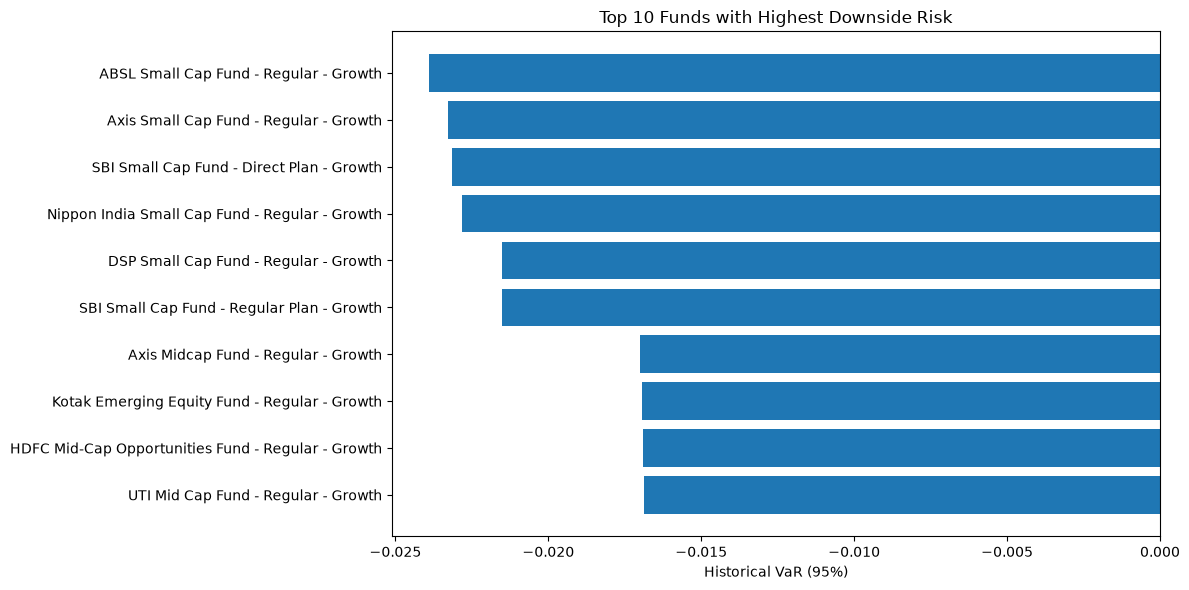

In [63]:
top10 = (
    risk_df
    .dropna(subset=["scheme_name"])
    .nsmallest(10, "VaR_95")
    .sort_values("VaR_95", ascending=False)
)

plt.figure(figsize=(12,6))

plt.barh(
    top10["scheme_name"],
    top10["VaR_95"]
)

plt.xlabel("Historical VaR (95%)")
plt.title("Top 10 Funds with Highest Downside Risk")

plt.tight_layout()
plt.show()

## Rolling 90-Day Sharpe Ratio

Unlike the overall Sharpe Ratio, the rolling Sharpe Ratio measures how a fund's risk-adjusted performance changes over time.

A 90-day rolling window is used to compute the average daily return and daily volatility. The annualized rolling Sharpe Ratio is calculated as:

Rolling Sharpe = (Rolling Mean Return / Rolling Standard Deviation) × √252

This visualization highlights changes in fund performance and consistency over time.

In [64]:
top5_funds = (
    fund_scorecard_df
    .sort_values("fund_score", ascending=False)
    .head(5)
)

top5_funds

,overall_rank,amfi_code,scheme_name,fund_score,cagr_3y,sharpe_ratio,alpha,expense_ratio_pct,max_drawdown,std_dev
0,1,148567,Mirae Asset Large Cap Fund - Regular - Growth,88.055556,0.340009,1.068224,0.269838,1.46,-0.112657,0.120250
1,2,120843,Kotak Flexicap Fund - Regular - Growth,83.333333,0.295828,0.965561,0.277943,1.45,-0.129740,0.134543
2,3,120505,ICICI Pru Midcap Fund - Regular - Growth,83.194444,0.317775,0.883256,0.293099,1.36,-0.181885,0.163311
3,4,120504,ICICI Pru Bluechip Fund - Direct - Growth,80.277778,0.324874,0.714682,0.211948,0.80,-0.125883,0.121592
4,5,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,80.138889,0.324425,0.808268,0.263347,1.38,-0.162172,0.160291


In [65]:
rolling_sharpe_df = daily_returns_df.copy()

rolling_sharpe_df = rolling_sharpe_df.dropna(subset=["daily_return"])

rolling_sharpe_df["rolling_sharpe"] = (
    rolling_sharpe_df
    .groupby("amfi_code")["daily_return"]
    .transform(
        lambda x:
        (
            x.rolling(90).mean()
            /
            x.rolling(90).std()
        ) * np.sqrt(252)
    )
)

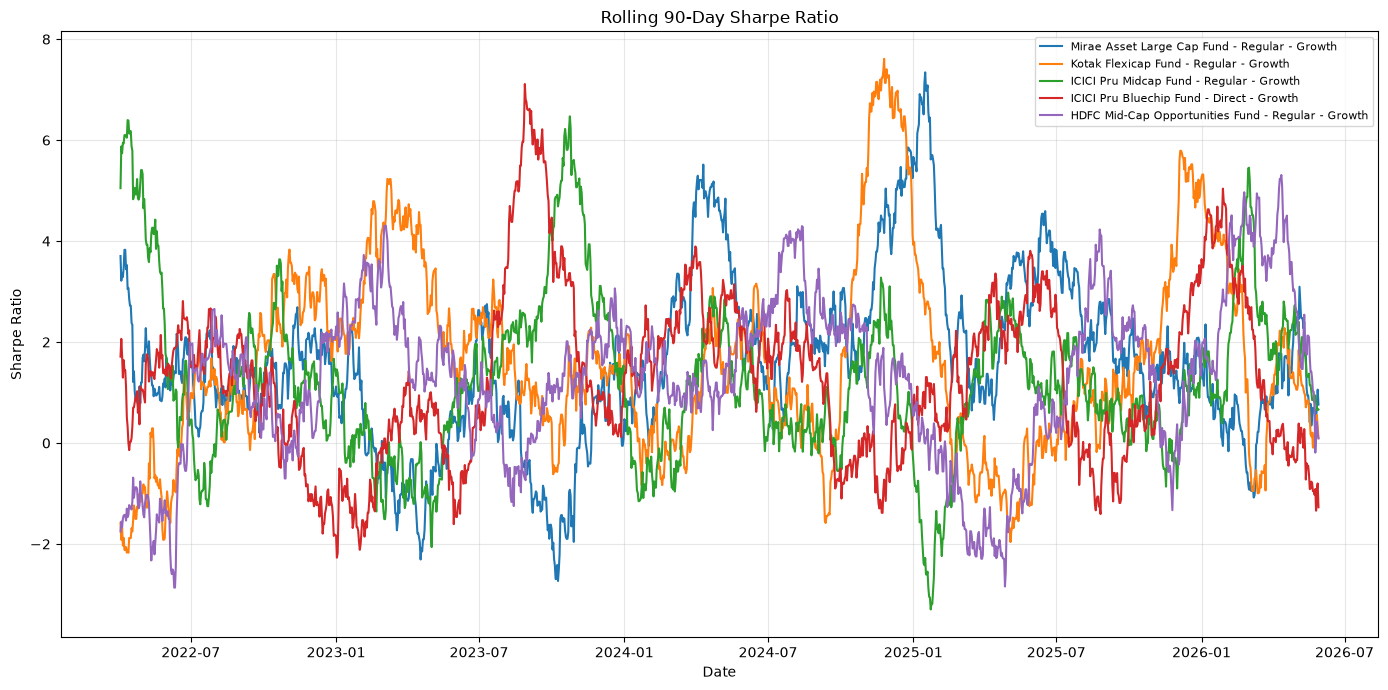

In [66]:
plt.figure(figsize=(14,7))

for _, fund in top5_funds.iterrows():

    fund_data = rolling_sharpe_df[
        rolling_sharpe_df["amfi_code"] == fund["amfi_code"]
    ]

    plt.plot(
        fund_data["date"],
        fund_data["rolling_sharpe"],
        label=fund["scheme_name"]
    )

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend(fontsize=8)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    REPORT_DIR / "rolling_sharpe_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [67]:
plt.savefig(
    REPORT_DIR / "rolling_sharpe_chart.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

### Observation

The rolling Sharpe ratios vary considerably over time, indicating that risk-adjusted fund performance is not constant. Some funds exhibit prolonged periods of high Sharpe ratios, suggesting sustained superior risk-adjusted returns, while others experience temporary declines into negative territory during volatile market conditions.

## Investor Cohort Analysis

Investor cohort analysis groups investors based on the year of their first investment transaction.

For each cohort, the following metrics are calculated:

- Average SIP investment amount
- Total investment amount
- Most preferred mutual fund

This helps identify long-term investment trends and changes in investor behaviour across different entry years.

In [68]:
cohort_df = investor_df.copy()

cohort_df["transaction_date"] = pd.to_datetime(
    cohort_df["transaction_date"]
)

In [69]:
first_transaction = (
    cohort_df
    .groupby("investor_id")["transaction_date"]
    .min()
)

cohort_df["cohort_year"] = (
    cohort_df["investor_id"]
    .map(first_transaction)
    .dt.year
)

In [70]:
sip_df = cohort_df[
    cohort_df["transaction_type"] == "SIP"
]

In [71]:
avg_sip = (
    sip_df
    .groupby("cohort_year")["amount_inr"]
    .mean()
)

In [72]:
total_investment = (
    cohort_df
    .groupby("cohort_year")["amount_inr"]
    .sum()
)

In [73]:
top_fund = (
    cohort_df
    .groupby(["cohort_year","amfi_code"])
    .size()
    .reset_index(name="count")
)

top_fund = (
    top_fund
    .sort_values(
        ["cohort_year","count"],
        ascending=[True,False]
    )
    .drop_duplicates("cohort_year")
)

In [74]:
scheme_map = scheme_df.set_index("amfi_code")["scheme_name"]

top_fund["top_fund"] = top_fund["amfi_code"].map(scheme_map)

In [75]:
cohort_report = pd.DataFrame({
    "Average SIP Amount": avg_sip,
    "Total Invested": total_investment
}).reset_index()

cohort_report = cohort_report.merge(
    top_fund[["cohort_year","top_fund"]],
    on="cohort_year",
    how="left"
)

cohort_report

,cohort_year,Average SIP Amount,Total Invested,top_fund
0,2024,10996.885825,3491125187,Mirae Asset Emerging Bluechip Fund - Regular -...
1,2025,13505.209581,30455243,SBI Small Cap Fund - Direct Plan - Growth


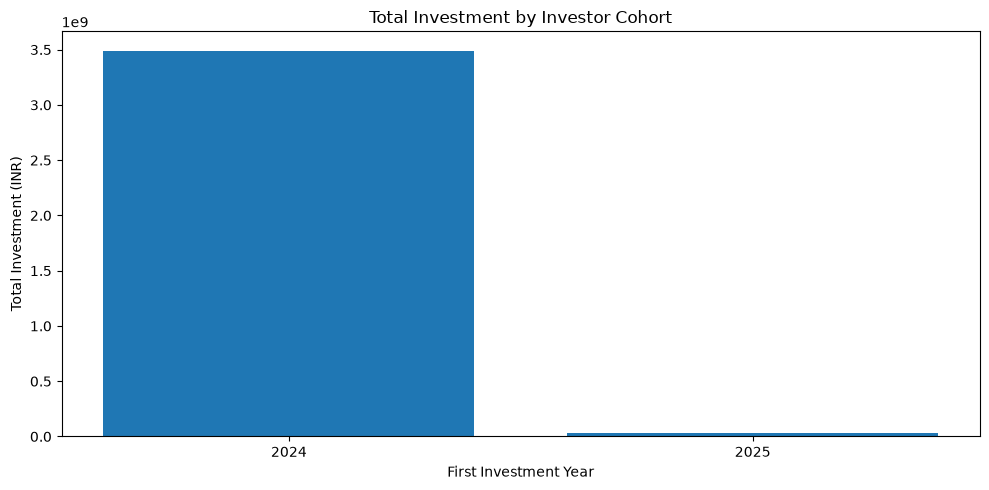

In [76]:
plt.figure(figsize=(10,5))

plt.bar(
    cohort_report["cohort_year"].astype(str),
    cohort_report["Total Invested"]
)

plt.title("Total Investment by Investor Cohort")
plt.xlabel("First Investment Year")
plt.ylabel("Total Investment (INR)")

plt.tight_layout()

plt.show()

In [77]:
cohort_report.to_csv(
    ANALYTICS_DIR / "cohort_analysis.csv",
    index=False
)

## SIP Continuity Analysis

Consistent SIP investing is an important indicator of disciplined investment behaviour.

For investors with at least six SIP transactions, the average gap between consecutive SIP dates is calculated.

Investors whose average gap exceeds 35 days are flagged as **At Risk**, indicating possible discontinuation or irregular investment behaviour.

In [78]:
sip_transactions = investor_df[
    investor_df["transaction_type"] == "SIP"
].copy()

sip_transactions["transaction_date"] = pd.to_datetime(
    sip_transactions["transaction_date"]
)

In [79]:
sip_transactions = sip_transactions.sort_values(
    ["investor_id", "transaction_date"]
)

In [80]:
sip_transactions["gap_days"] = (
    sip_transactions
    .groupby("investor_id")["transaction_date"]
    .diff()
    .dt.days
)

In [81]:
sip_summary = (
    sip_transactions
    .groupby("investor_id")
    .agg(
        sip_count=("transaction_date", "count"),
        avg_gap_days=("gap_days", "mean")
    )
)

sip_summary = sip_summary[
    sip_summary["sip_count"] >= 6
]

In [82]:
sip_summary["status"] = np.where(
    sip_summary["avg_gap_days"] > 35,
    "At Risk",
    "Active"
)

In [83]:
sip_summary.head()

,sip_count,avg_gap_days,status
investor_id,,,
INV000004,6,85.400000,At Risk
INV000008,6,70.400000,At Risk
INV000010,6,64.800000,At Risk
INV000011,7,40.166667,At Risk
INV000012,8,57.000000,At Risk


In [84]:
sip_summary.to_csv(
    ANALYTICS_DIR / "sip_continuity_report.csv"
)

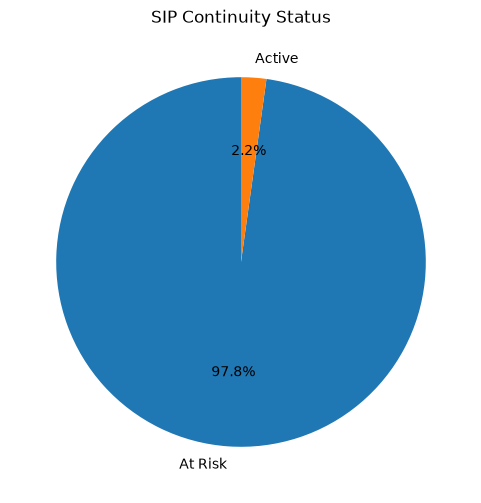

In [85]:
status_counts = sip_summary["status"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    status_counts,
    labels=status_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("SIP Continuity Status")

plt.show()

## Sector Concentration Analysis (Herfindahl-Hirschman Index)

The Herfindahl-Hirschman Index (HHI) measures portfolio concentration by summing the squared portfolio weights of individual holdings.

HHI close to 1 indicates a highly concentrated portfolio.

Lower HHI values indicate better diversification across holdings.

In [86]:
portfolio_df.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [87]:
portfolio_hhi = portfolio_df.copy()

portfolio_hhi["weight"] = (
    portfolio_hhi["weight_pct"] / 100
)

In [88]:
hhi_df = (
    portfolio_hhi
    .groupby("amfi_code")["weight"]
    .apply(lambda x: (x ** 2).sum())
    .reset_index(name="HHI")
)

In [89]:
scheme_map = scheme_df[
    ["amfi_code", "scheme_name"]
]

hhi_df = hhi_df.merge(
    scheme_map,
    on="amfi_code",
    how="left"
)

In [90]:
hhi_df = hhi_df.sort_values(
    "HHI",
    ascending=False
)

hhi_df.head()

,amfi_code,HHI,scheme_name
11,119092,0.206448,Axis Bluechip Fund - Regular - Growth
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth
18,119599,0.174751,SBI Small Cap Fund - Direct Plan - Growth
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth
7,118632,0.168298,Nippon India Large Cap Fund - Regular - Growth


In [91]:
hhi_df.to_csv(
    ANALYTICS_DIR / "sector_hhi.csv",
    index=False
)

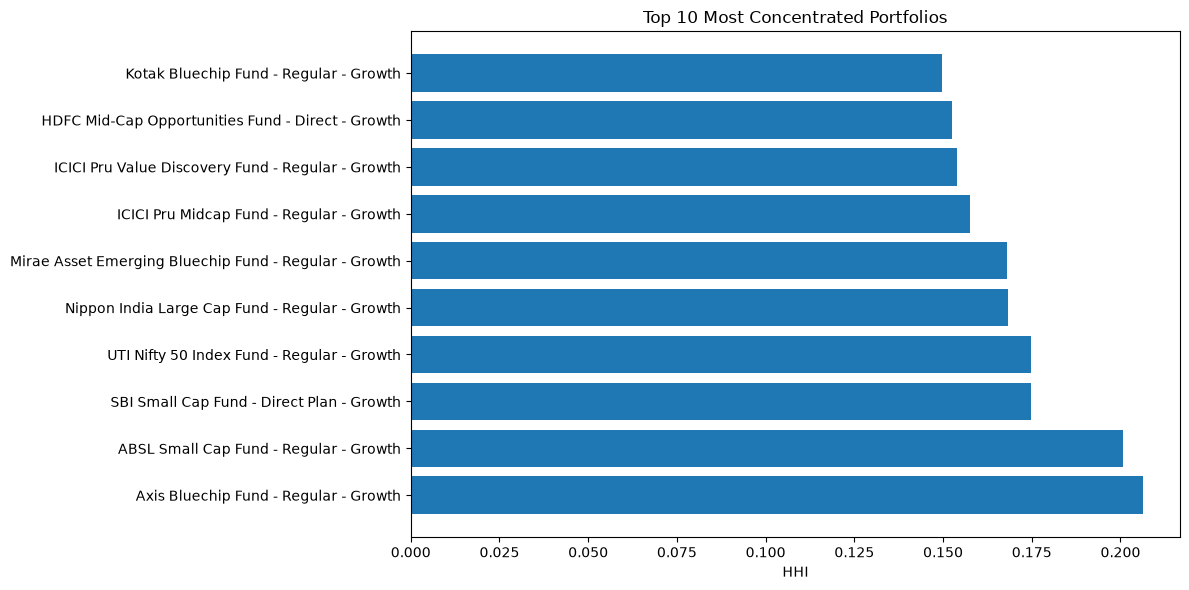

In [92]:
top10 = hhi_df.head(10)

plt.figure(figsize=(12,6))

plt.barh(
    top10["scheme_name"],
    top10["HHI"]
)

plt.xlabel("HHI")
plt.title("Top 10 Most Concentrated Portfolios")

plt.tight_layout()

plt.show()

## Fund Recommendation System

A rule-based mutual fund recommendation system was developed as a separate Python script (`scripts/recommender.py`).

The recommender accepts one of the following investor risk appetites:

- Low
- Moderate
- High

Based on the selected risk appetite, the script filters funds by their corresponding risk grade and recommends the top three mutual funds ranked by Sharpe Ratio. This provides a simple decision-support tool that combines historical performance with investor risk preferences.

In [93]:
recommendation_example = pd.DataFrame({
    "Risk Appetite": ["Moderate"],
    "Top Recommendation": ["Mirae Asset Large Cap Fund - Regular - Growth"]
})

recommendation_example

,Risk Appetite,Top Recommendation
0,Moderate,Mirae Asset Large Cap Fund - Regular - Growth


# Key Insights

### 1. Downside Risk
Historical VaR and CVaR analysis identified small-cap and mid-cap funds as having the highest downside risk, indicating greater sensitivity to adverse market movements.

### 2. Rolling Risk-Adjusted Performance
The rolling 90-day Sharpe Ratio showed that risk-adjusted performance varied significantly over time. Several funds maintained strong Sharpe ratios for extended periods, while others experienced negative Sharpe ratios during volatile market conditions.

### 3. Investor Cohort Behaviour
The 2024 investor cohort accounted for the largest share of total investments, contributing substantially more capital than investors who entered in 2025. This indicates that most investment activity originated from earlier participants.

### 4. SIP Continuity
Most investors with six or more SIP transactions were classified as **At Risk** because their average investment interval exceeded 35 days. This suggests irregular SIP contribution patterns within the dataset.

### 5. Portfolio Concentration
Sector concentration analysis using the Herfindahl-Hirschman Index (HHI) revealed noticeable differences in portfolio diversification. Axis Bluechip Fund and ABSL Small Cap Fund recorded the highest HHI values, indicating comparatively concentrated portfolios.